In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# loading dataset
data = load_breast_cancer()
X, y = data.data, data.target
X.shape, y.shape

((569, 30), (569,))

In [ ]:
# Using iloc (integer location indexing)
X[0]  # or
X[0, :]  # explicitly get all columns of row 0

# Using numpy
np.take(X, 0, axis=0)

# Using advanced indexing
X[[0]]  # returns 2D array instead of 1D

array([1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
       3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
       8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
       3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
       1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01])

In [4]:
y[0]

np.int64(0)

In [5]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [6]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# data standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# defining model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # Input
    layers.Dense(32, activation="relu"), # layer 1 with 32 neurons
    layers.Dropout(0.3), # 30% of neurons in the previous layer are randomly turned off during each training step
    layers.Dense(16, activation="relu"), # layer 2 with 16 neurons
    layers.Dense(1, activation="sigmoid")  # layer 3 with 1 neuron
])

In [11]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [13]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5769 - loss: 0.6753 - val_accuracy: 0.9231 - val_loss: 0.4312
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8874 - loss: 0.4389 - val_accuracy: 0.9560 - val_loss: 0.2779
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9533 - loss: 0.2584 - val_accuracy: 0.9780 - val_loss: 0.1886
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9478 - loss: 0.1941 - val_accuracy: 0.9780 - val_loss: 0.1447
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9533 - loss: 0.1551 - val_accuracy: 0.9780 - val_loss: 0.1177
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.1243 - val_accuracy: 0.9780 - val_loss: 0.1002
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9560 - loss: 0.1224 - val_accuracy: 0.9780 - val_loss: 0.0874
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.1053 - val_accuracy: 0.9890 - val_loss

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9649


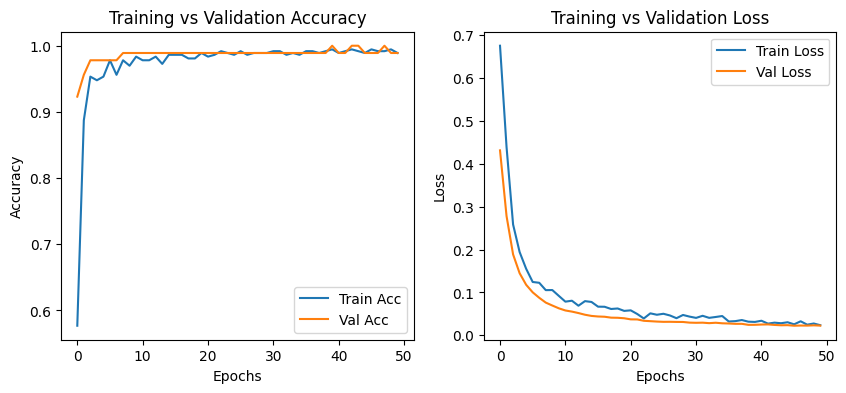

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# plotting accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# plotting loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

#### Assignment
- Train a feed-forward neural network to solve a multi-class classification task. You can use a dataset of your choice from scikit-learn or kaggle. Use the ``Weights and Biases`` Python library for visualization during model training, and take screenshots of your dashboard. Compute relevant performance metrics and save your model.


In [19]:
# Dataset and Weights and Biases import

from sklearn.datasets import fetch_covtype
import wandb

from dotenv import load_dotenv
import os

load_dotenv()

import wandb
wandb.login(key=os.getenv("WANDB_API_KEY"))

wandb.init(project="classification-nn")

data = fetch_covtype

X, y = fetch_covtype(return_X_y=True)

#Since the dataset is soo big we scale it down
X = X[:50000] 
y= y[:50000]

# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# data standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


wandb.init(project ="classification-nn")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\user\_netrc


wandb: Currently logged in as: melissaviolet (models-makerere-university734) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [27]:
# Model definition
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(8, activation='softmax')  # 7 classes
])

In [28]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
#Train with W&B logging

from wandb.integration.keras import WandbMetricsLogger

model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[WandbMetricsLogger()]
)

Epoch 1/50


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6960 - loss: 0.8589 - val_accuracy: 0.7761 - val_loss: 0.5772
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7898 - loss: 0.5331 - val_accuracy: 0.7975 - val_loss: 0.5107
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8054 - loss: 0.4883 - val_accuracy: 0.7996 - val_loss: 0.4864
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8156 - loss: 0.4656 - val_accuracy: 0.8066 - val_loss: 0.4728
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8238 - loss: 0.4493 - val_accuracy: 0.8204 - val_loss: 0.4522
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8310 - loss: 0.4362 - val_accuracy: 0.8226 - val_loss: 0.4430
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8351 - loss: 0.4268 - val_accuracy: 0.8276 - val_loss: 0.4357
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8374 - loss: 0.4194 - val_accurac

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

preds = model.predict(X)
preds = preds.argmax(axis=1)

print(classification_report(y, preds))

- Use the PyTorch Python library to train a feedforward neural network to solve a regression task. You can use a dataset of your choice. Implement checkpointing and earlystopping. Compute relevant performance metrics and save your best model